In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Loading dataset...
Found 12783 validated image filenames belonging to 10 classes.
Found 3195 validated image filenames belonging to 10 classes.
Found 1776 validated image filenames belonging to 10 classes.
Classes: {'bacterial_spot': 0, 'early_blight': 1, 'healthy': 2, 'late_blight': 3, 'leaf_mold': 4, 'mosaic_virus': 5, 'septoria_leaf_spot': 6, 'target_spot': 7, 'twospotted_spider_mite': 8, 'yellow_leaf_curl_virus': 9}
Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 161s 635ms/step - accuracy: 0.4211 - loss: 1.7193 - val_accuracy: 0.8347 - val_loss: 0.5835
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 90s 451ms/step - accuracy: 0.7883 - loss: 0.6378 - val_accuracy: 0.8942 - val_loss: 0.3630
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 92s 459ms/step - accuracy: 0.8644 - loss: 0.4389 - val_accuracy: 0.9111 - val_loss: 0.2864
Saving model (SavedModel format)...
Evaluating...
Test Accuracy: 91.16%


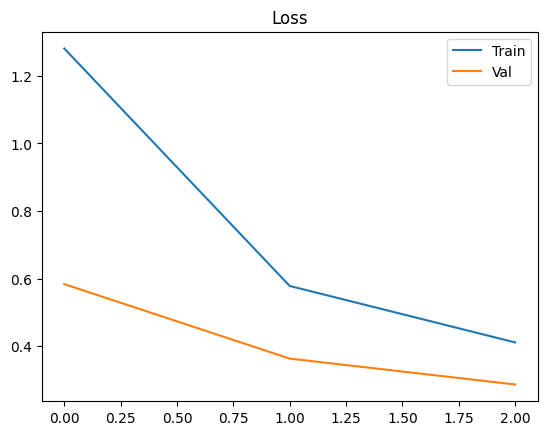

In [7]:
import os
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# DATASET PATH (COLAB)
# ---------------------------------------------------------
DATASET_PATH = r"/content/drive/MyDrive/Datasets/tomato/train"
MODEL_SAVE_PATH = r"/content/drive/MyDrive/Datasets/tomato/model_tomato_disease.keras"

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 3

# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------
def load_dataset(path):
    filepaths = []
    labels = []

    for class_name in os.listdir(path):
        class_path = os.path.join(path, class_name)
        if os.path.isdir(class_path):
            for img in os.listdir(class_path):
                if img.lower().endswith((".jpg", ".png", ".jpeg")):
                    filepaths.append(os.path.join(class_path, img))
                    labels.append(class_name)

    return pd.DataFrame({"Filepath": filepaths, "Label": labels})


# ---------------------------------------------------------
# Hybrid Model: EfficientNetB0 + ConvNeXtTiny
# ---------------------------------------------------------
def build_hybrid_model(num_classes):

    effnet = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        pooling="avg",
        input_shape=(224, 224, 3)
    )
    effnet.trainable = False

    convnext = tf.keras.applications.ConvNeXtTiny(
        include_top=False,
        weights="imagenet",
        pooling="avg",
        input_shape=(224, 224, 3)
    )
    convnext.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))

    x1 = effnet(inputs)
    x2 = convnext(inputs)

    x = tf.keras.layers.Concatenate()([x1, x2])
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs)


# ---------------------------------------------------------
# Train
# ---------------------------------------------------------
def train():

    print("Loading dataset...")
    df = load_dataset(DATASET_PATH)

    train_df, test_df = train_test_split(
        df, train_size=0.9, stratify=df["Label"], random_state=42
    )

    train_gen = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
        validation_split=0.2,
        horizontal_flip=True
    )

    test_gen = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
    )

    train_images = train_gen.flow_from_dataframe(
        train_df,
        x_col="Filepath",
        y_col="Label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        subset="training"
    )

    val_images = train_gen.flow_from_dataframe(
        train_df,
        x_col="Filepath",
        y_col="Label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        subset="validation"
    )

    test_images = test_gen.flow_from_dataframe(
        test_df,
        x_col="Filepath",
        y_col="Label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    print("Classes:", train_images.class_indices)

    model = build_hybrid_model(num_classes=len(train_images.class_indices))

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=3, restore_best_weights=True
        )
    ]

    print("Training...")
    history = model.fit(
        train_images,
        validation_data=val_images,
        epochs=EPOCHS,
        callbacks=callbacks
    )

    print("Saving model (SavedModel format)...")
    model.save(MODEL_SAVE_PATH)

    print("Evaluating...")
    loss, acc = model.evaluate(test_images, verbose=0)
    print(f"Test Accuracy: {acc * 100:.2f}%")

    # Accuracy plot
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.legend(["Train", "Val"])
    plt.title("Accuracy")
    plt.savefig("/content/drive/MyDrive/Datasets/tomato/accuracy.png")
    plt.clf()

    # Loss plot
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.legend(["Train", "Val"])
    plt.title("Loss")
    plt.savefig("/content/drive/MyDrive/Datasets/tomato/loss.png")


train()
